## Standard Form

$$\frac{dy}{dx}+P(x)y=Q(x)$$

## Python Setup

In [1]:
# Install if needed:
# pip install sympy scipy numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

# Pretty printing for sympy
sp.init_printing()

## Example 1: The Simplest Case

$$\frac{d y}{dx}=y\;,\;y(0)=1$$

In [2]:
x = sp.symbols('x')
y = sp.Function('y')

# Define ODE: y' - y = 0
ode = sp.Eq(y(x).diff(x) - y(x), 0)

# Solve symbolically
sol = sp.dsolve(ode, y(x), ics={y(0): 1})
print(sol)

Eq(y(x), exp(x))


### Numerical verification

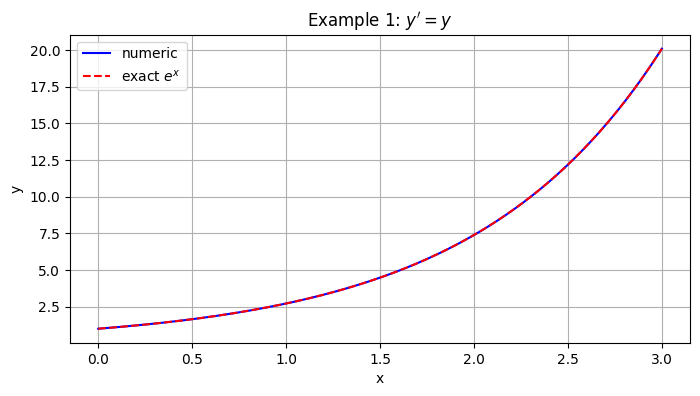

In [3]:
# Numerical verification
f = lambda x, y: y
sol_num = solve_ivp(f, [0, 3], [1], t_eval=np.linspace(0,3,200))

plt.figure(figsize=(8,4))
plt.plot(sol_num.t, sol_num.y[0], 'b-', label='numeric')
xs = np.linspace(0,3,200)
plt.plot(xs, np.exp(xs), 'r--', label='exact $e^x$')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True)
plt.title('Example 1: $y\' = y$'); plt.show()

## Example 2: Constant Coefficients, Non-Homogeneous

$$\frac{d y}{dx}+2y=4\;,\;y(0)=0$$

In [4]:
ode = sp.Eq(y(x).diff(x) + 2*y(x), 4)
sol = sp.dsolve(ode, y(x), ics={y(0): 0})
print(sol)

Eq(y(x), 2 - 2*exp(-2*x))


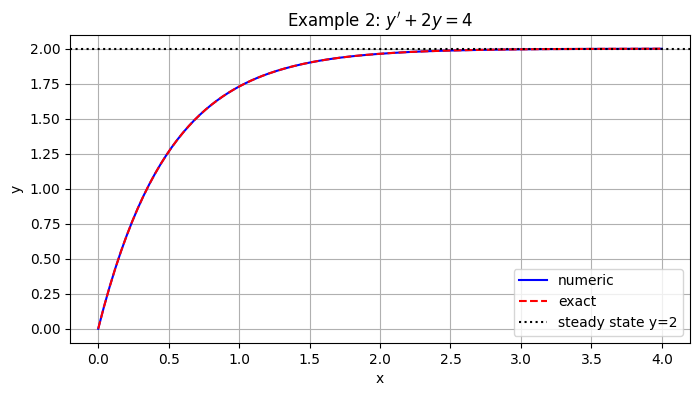

In [5]:
f = lambda x, y: 4 - 2*y
sol_num = solve_ivp(f, [0, 4], [0], t_eval=np.linspace(0,4,200))

plt.figure(figsize=(8,4))
plt.plot(sol_num.t, sol_num.y[0], 'b-', label='numeric')
xs = np.linspace(0,4,200)
plt.plot(xs, 2*(1-np.exp(-2*xs)), 'r--', label='exact')
plt.axhline(2, color='k', linestyle=':', label='steady state y=2')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True)
plt.title('Example 2: $y\' + 2y = 4$'); plt.show()

## Example 3: P(x) Constant, Q(x) Varies

$$\frac{d y}{dx}+y=x\;,\;y(0)=0$$

In [6]:
ode = sp.Eq(y(x).diff(x) + y(x), x)
sol = sp.dsolve(ode, y(x), ics={y(0): 0})
print(sol)

Eq(y(x), x - 1 + exp(-x))


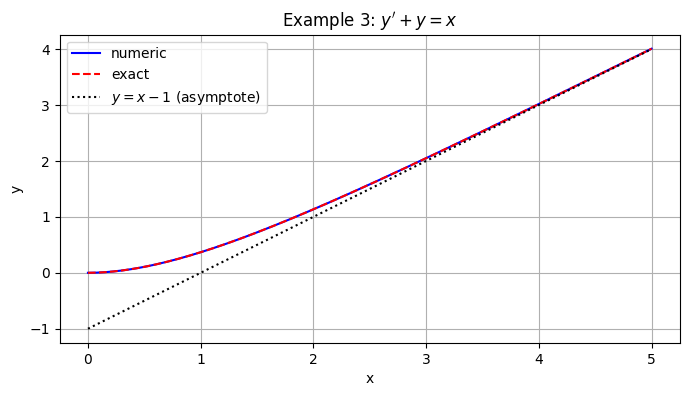

In [7]:
f = lambda x, y: x - y
sol_num = solve_ivp(f, [0, 5], [0], t_eval=np.linspace(0,5,200))

plt.figure(figsize=(8,4))
plt.plot(sol_num.t, sol_num.y[0], 'b-', label='numeric')
xs = np.linspace(0,5,200)
plt.plot(xs, xs - 1 + np.exp(-xs), 'r--', label='exact')
plt.plot(xs, xs - 1, 'k:', label='$y=x-1$ (asymptote)')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True)
plt.title('Example 3: $y\' + y = x$'); plt.show()